# Imports

In [4]:
import pandas as pd
import numpy as np
import os
from funciones_pre_procesamiento import plot_corr, plot_all, plot_all_timeseries, analizar_columnas_por_fecha, build_active_flag, blocks_from_flag, plot_with_active_blocks, bloques_sin_datos_global, imprimir_bloques

# Limpieza

In [5]:
desc_planta_1 = pd.read_csv('../Proyecto Herramienta para monitoreo de la calidad de datos/2. Datos/planta_1/planta_1_descripcion.csv')
df_planta_1 = pd.read_csv('../Proyecto Herramienta para monitoreo de la calidad de datos/2. Datos/planta_1/planta_1_datos.csv')

In [6]:
df_planta_1.info()
desc_planta_1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82380 entries, 0 to 82379
Data columns (total 28 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   date_time                                  82380 non-null  object 
 1   Conductividad                              0 non-null      float64
 2   Conductividad DAF                          81992 non-null  float64
 3   Fecha                                      0 non-null      float64
 4   Flujo Parshall 01 entrada a Ecualizador 1  81994 non-null  float64
 5   Flujo de envío a DAF                       81996 non-null  float64
 6   Hora                                       0 non-null      float64
 7   Nivel Ecualizador 1 (Tk 30m3)              82001 non-null  float64
 8   Nivel Ecualizador 2 (Tk 250m3)             82005 non-null  float64
 9   PH Coagulación                             94 non-null     float64
 10  Temperatura DAF       

,name,unit,type_var,periodicity,critical_max_value,warning_max_value,warning_min_value,critical_min_value
0,Conductividad,mS/cm,conductividad,1 minutes,NaN,NaN,NaN,NaN
1,Conductividad DAF,mS/cm,conductividad,1 minutes,0.7,0.5,0.0,0.00
2,Fecha,Dia,horometro,1 minutes,NaN,NaN,NaN,NaN
3,Flujo Parshall 01 entrada a Ecualizador 1,m3/hr,caudal,1 minutes,30.0,NaN,NaN,0.00
4,Flujo de envío a DAF,m3/hr,caudal,1 minutes,30.0,NaN,NaN,NaN
5,Hora,min,horometro,1 minutes,NaN,NaN,NaN,NaN
6,Nivel Ecualizador 1 (Tk 30m3),%,nivel,1 minutes,NaN,80.0,10.0,5.00
7,Nivel Ecualizador 2 (Tk 250m3),%,nivel,1 minutes,95.0,90.0,10.0,5.00
8,PH Coagulación,-,ph,1 minutes,6.0,NaN,NaN,5.40
9,Temperatura DAF,°C,temperatura,1 minutes,35.0,30.0,5.0,5.00


In [7]:
df_planta_1['date_time'] = pd.to_datetime(df_planta_1['date_time'])

df_planta_1.dropna(axis=1, how='all', inplace= True)
df_planta_1.drop(columns=['PH Coagulación'], inplace=True)

df_planta_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82380 entries, 0 to 82379
Data columns (total 16 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   date_time                                  82380 non-null  datetime64[ns]
 1   Conductividad DAF                          81992 non-null  float64       
 2   Flujo Parshall 01 entrada a Ecualizador 1  81994 non-null  float64       
 3   Flujo de envío a DAF                       81996 non-null  float64       
 4   Nivel Ecualizador 1 (Tk 30m3)              82001 non-null  float64       
 5   Nivel Ecualizador 2 (Tk 250m3)             82005 non-null  float64       
 6   Temperatura DAF                            82007 non-null  float64       
 7   pH Clarificado DAF (Tk 80m3)               82007 non-null  float64       
 8   pH Ecualizador 2 (Tk 250m3)                67566 non-null  float64       
 9   pH coagulación en

In [8]:
df_planta_1.describe()

,date_time,Conductividad DAF,Flujo Parshall 01 entrada a Ecualizador 1,Flujo de envío a DAF,Nivel Ecualizador 1 (Tk 30m3),Nivel Ecualizador 2 (Tk 250m3),Temperatura DAF,pH Clarificado DAF (Tk 80m3),pH Ecualizador 2 (Tk 250m3),pH coagulación entrada DAF,pH entrada a Ecualizador 2 (Tk 250m3),pH salida a Parshall 02,Nivel Clarificado DAF (Tk 80m3),pH entrada a Ecualizador 1,Turbidez salida DAF,pH salida y control Ecualizador 1
count,82380,81992.000000,81994.000000,81996.000000,82001.000000,82005.000000,82007.000000,82007.000000,67566.000000,82011.000000,82009.000000,82009.000000,82012.000000,82013.000000,82010.000000,82007.000000
mean,2025-06-29 22:55:00.041514752,55.993934,5.651404,2.791925,72.429208,58.902851,0.002305,7.021673,0.001865,6.693540,4.876539,7.157002,36.785964,0.019012,639.207789,6.597263
min,2024-08-13 00:00:00,0.000000,0.000000,0.000000,42.000000,22.560764,0.000000,4.985171,0.000000,0.139757,0.933232,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2025-06-06 18:55:45,0.047743,3.675347,0.086806,66.822918,27.508680,0.000000,6.077148,0.000000,6.091074,4.784143,6.394387,12.783203,0.000000,1.591435,5.885764
50%,2025-07-05 23:42:30,0.093678,5.085070,0.130208,75.046295,70.810184,0.000000,7.122034,0.000000,6.936198,4.873770,6.906829,21.617840,0.000000,5.931713,6.792188
75%,2025-07-20 18:36:15,0.134549,6.847222,6.759983,80.000000,78.223381,0.000000,7.779297,0.000000,7.227358,4.962384,7.937789,59.820965,0.000000,492.006653,7.610764
max,2025-08-09 23:58:00,500.000000,107.415794,42.000000,80.000000,89.039352,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,90.000000,42.000000,4000.000000,42.000000
std,NaN,157.364673,3.430711,3.909135,8.389577,23.931608,0.302349,0.866152,0.279859,1.052294,0.279103,1.579460,27.870516,0.431945,1212.701532,2.198820


# Gráficas

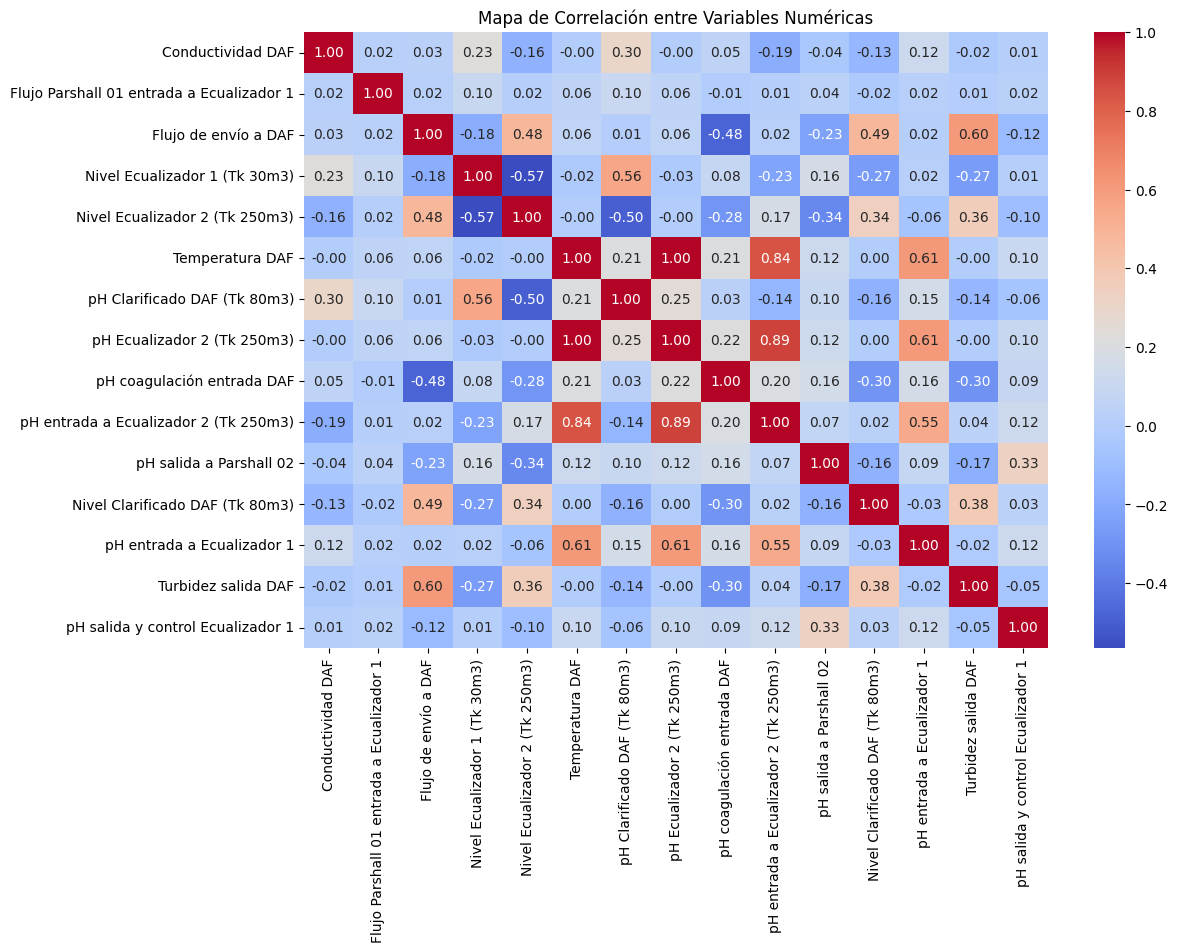

In [9]:
plot_corr(df_planta_1)

Graficando Conductividad DAF (se agregan límites si existen)


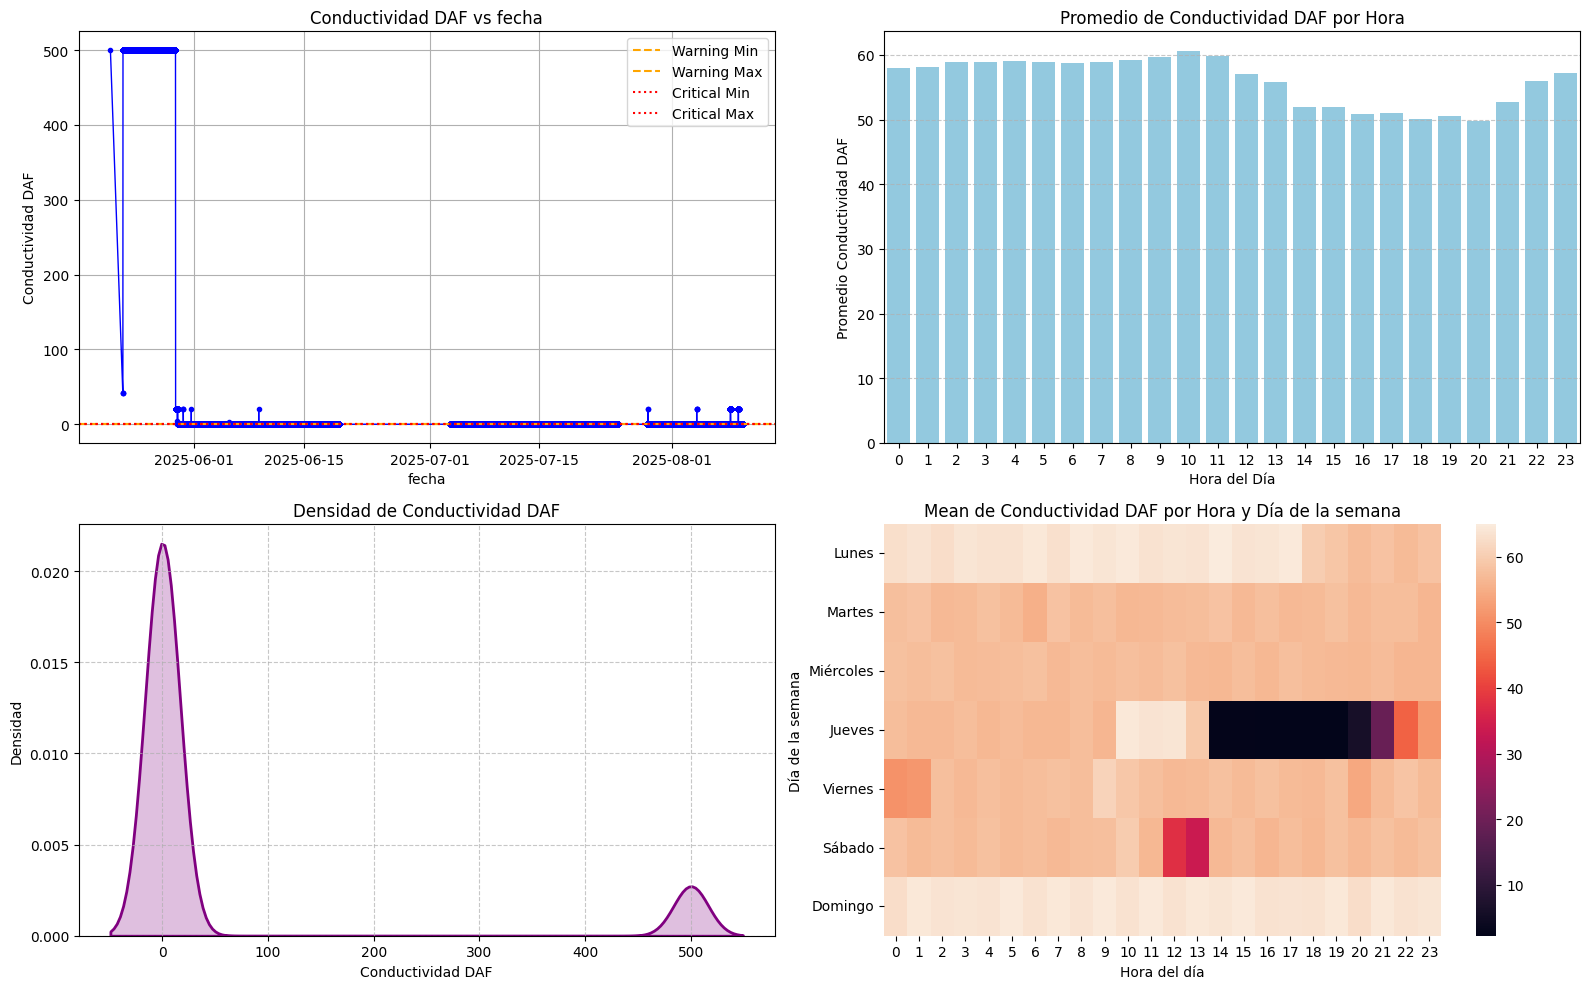

Graficando Flujo Parshall 01 entrada a Ecualizador 1 (se agregan límites si existen)


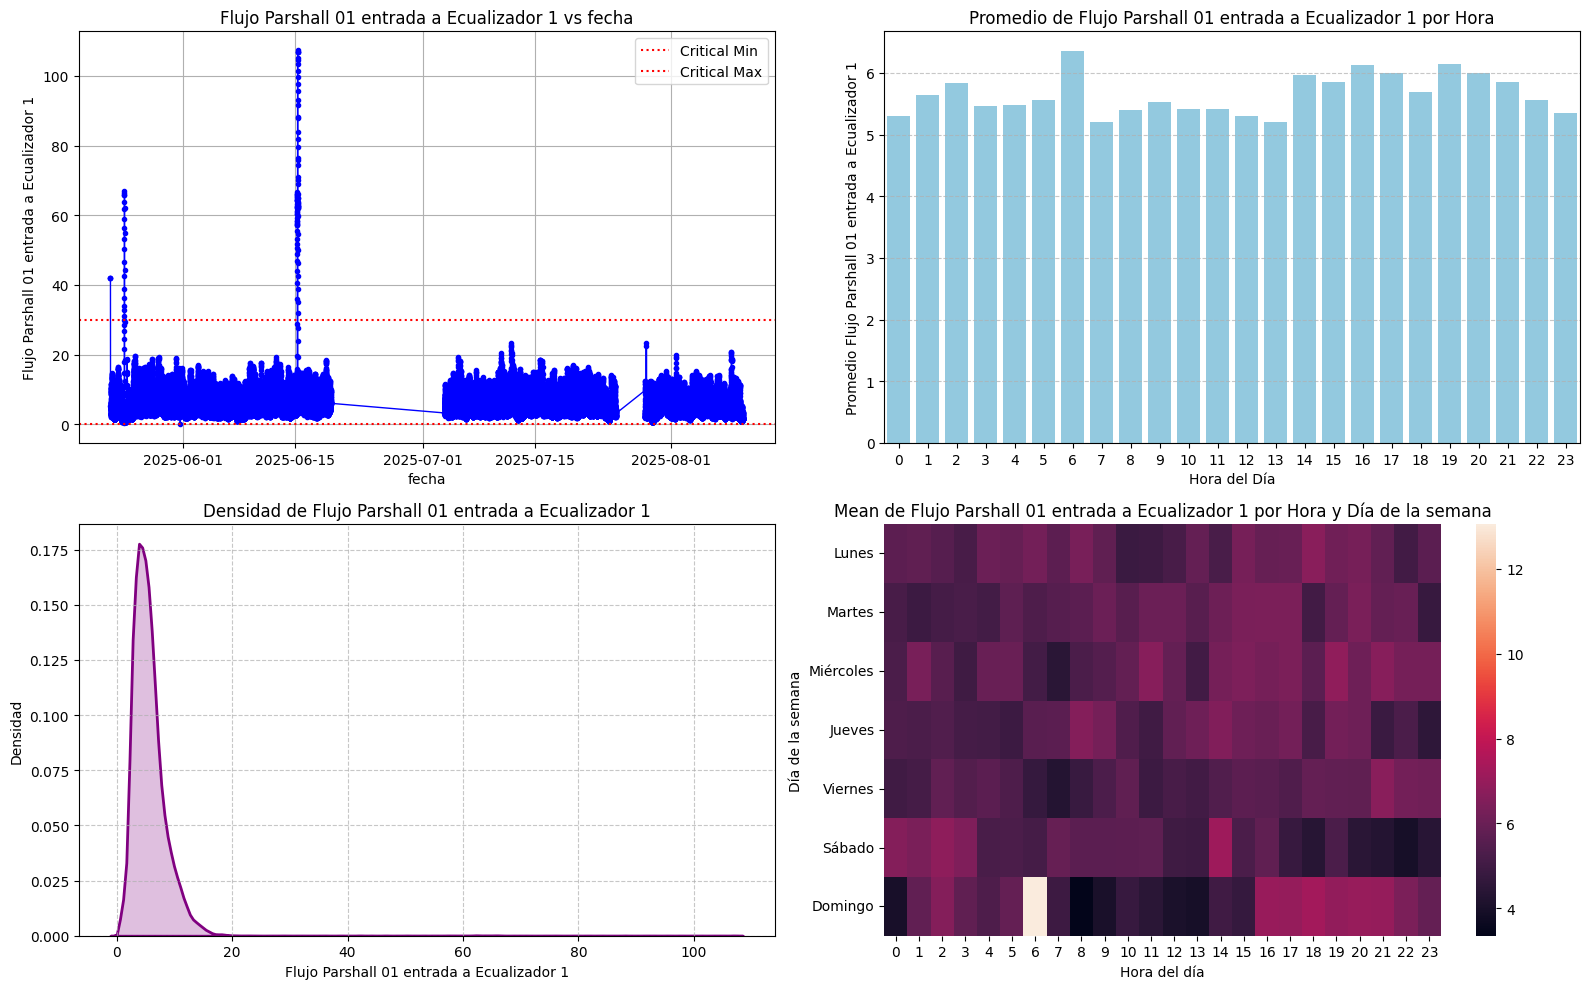

Graficando Flujo de envío a DAF (se agregan límites si existen)


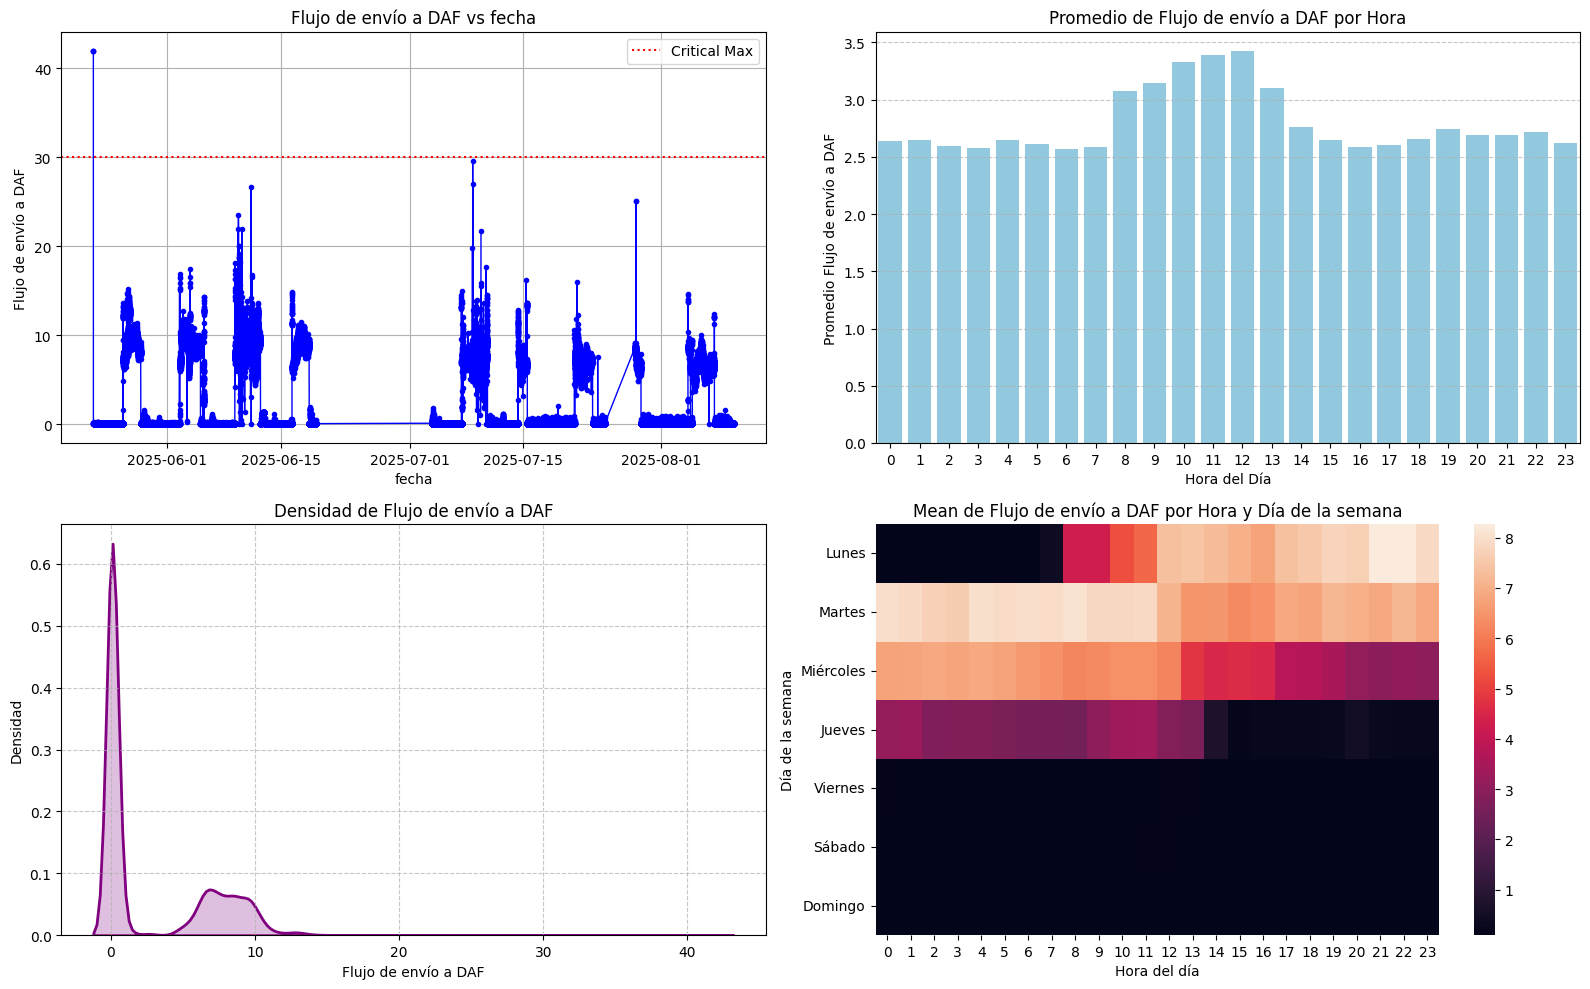

Graficando Nivel Ecualizador 1 (Tk 30m3) (se agregan límites si existen)


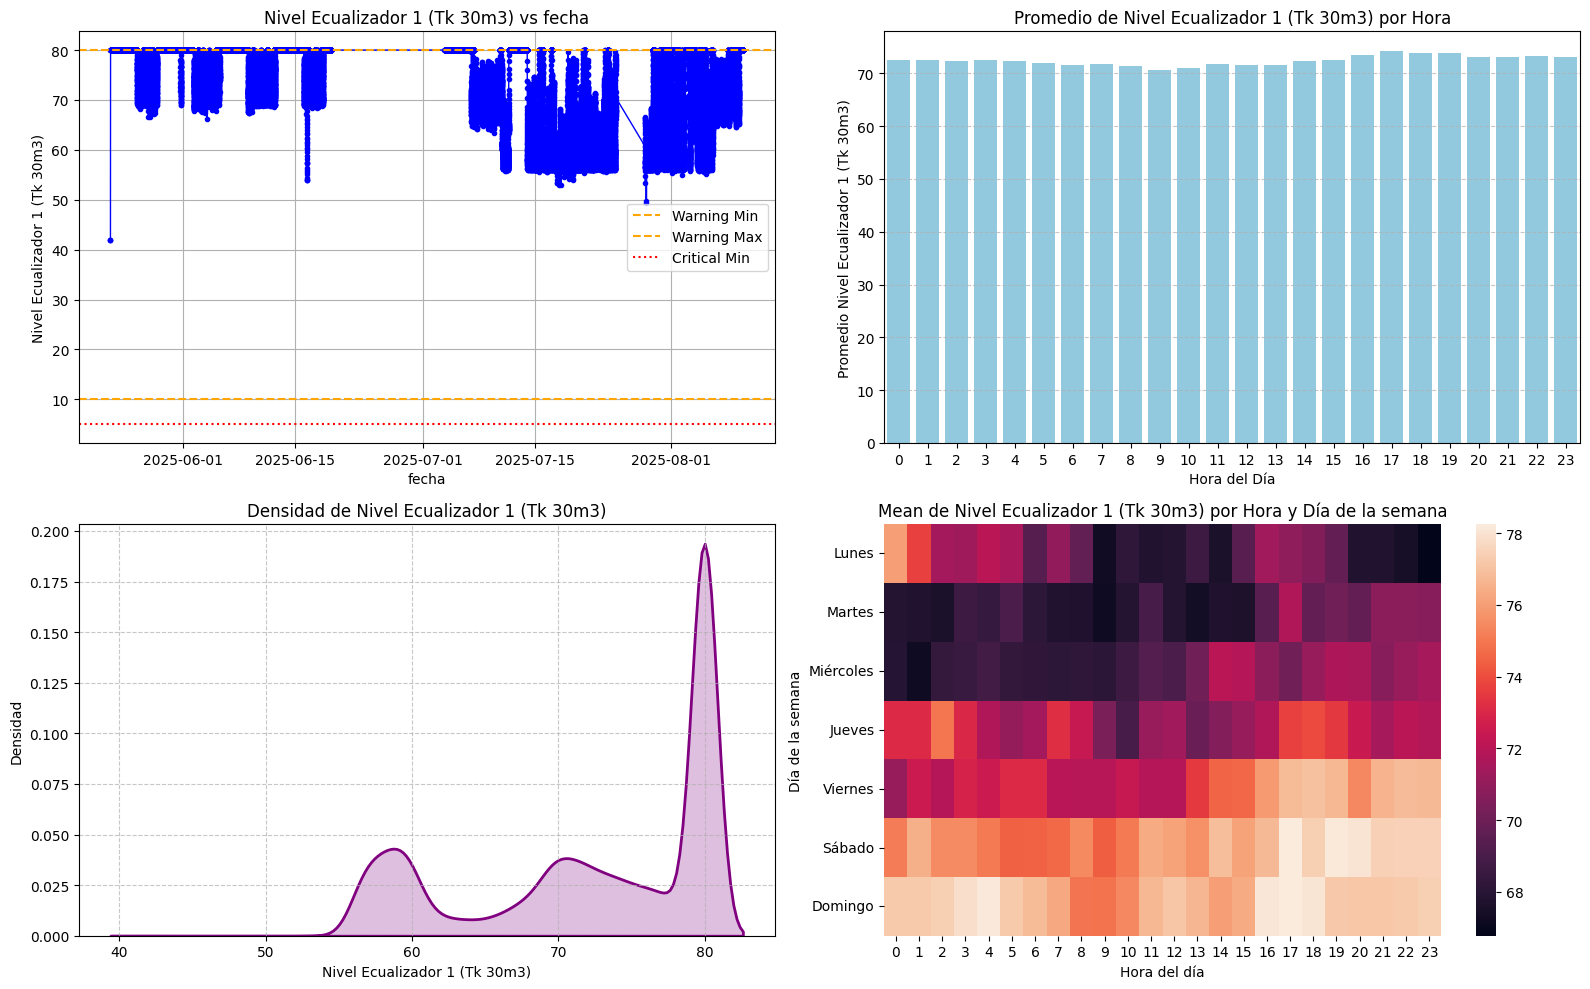

Graficando Nivel Ecualizador 2 (Tk 250m3) (se agregan límites si existen)


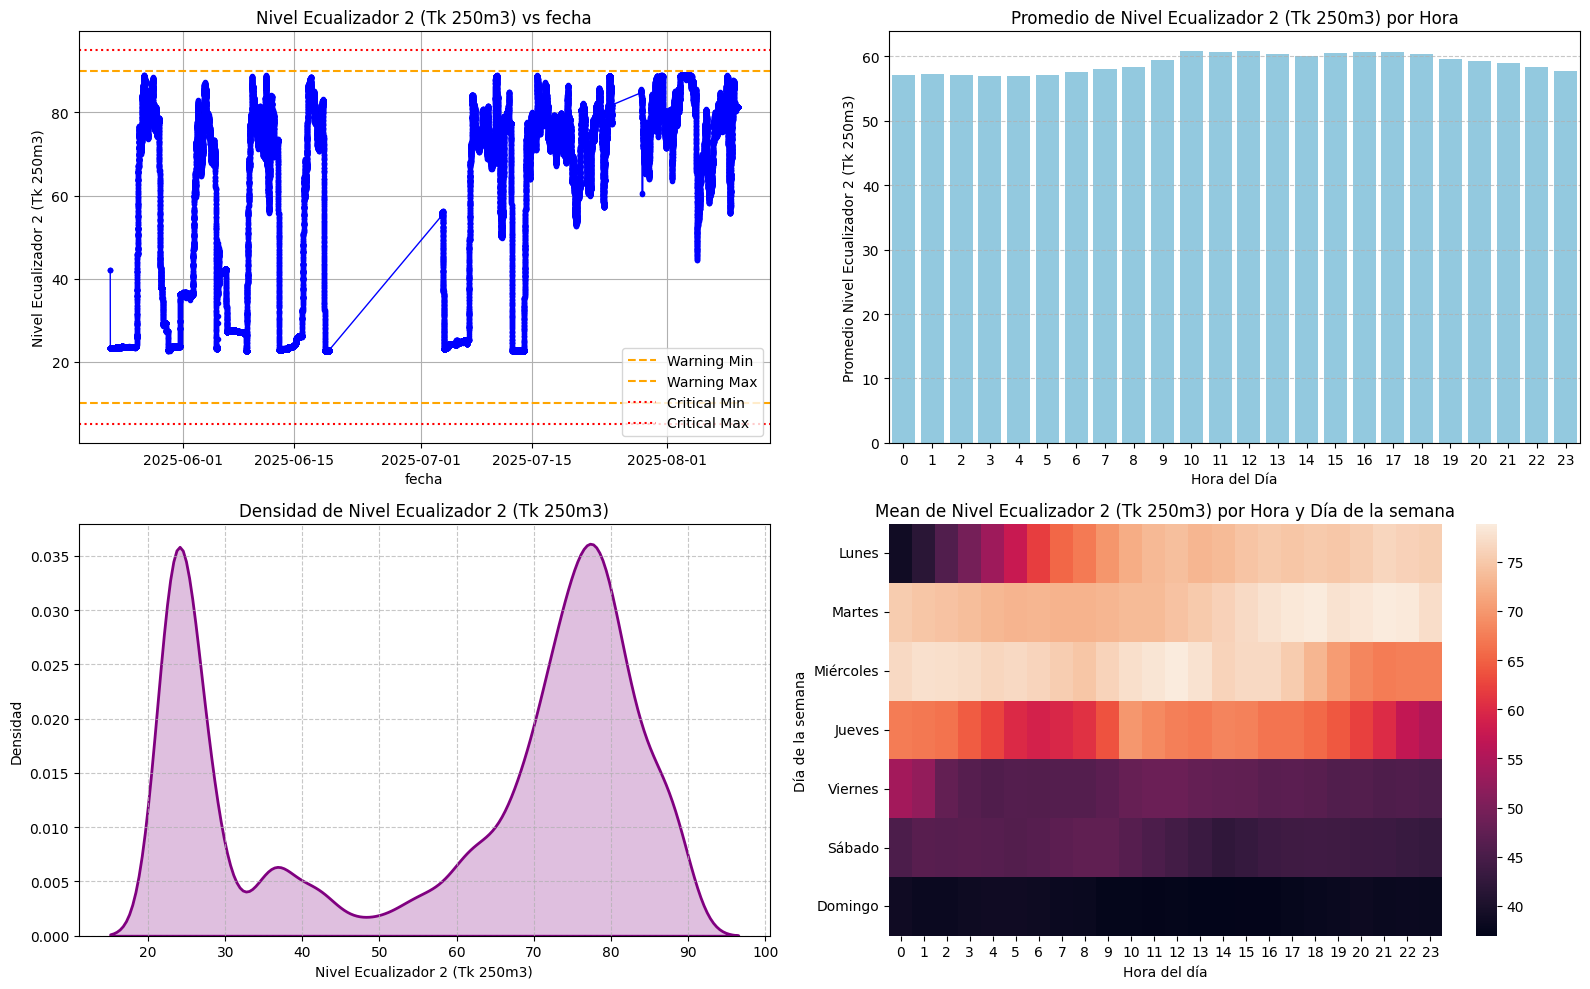

Graficando Temperatura DAF (se agregan límites si existen)


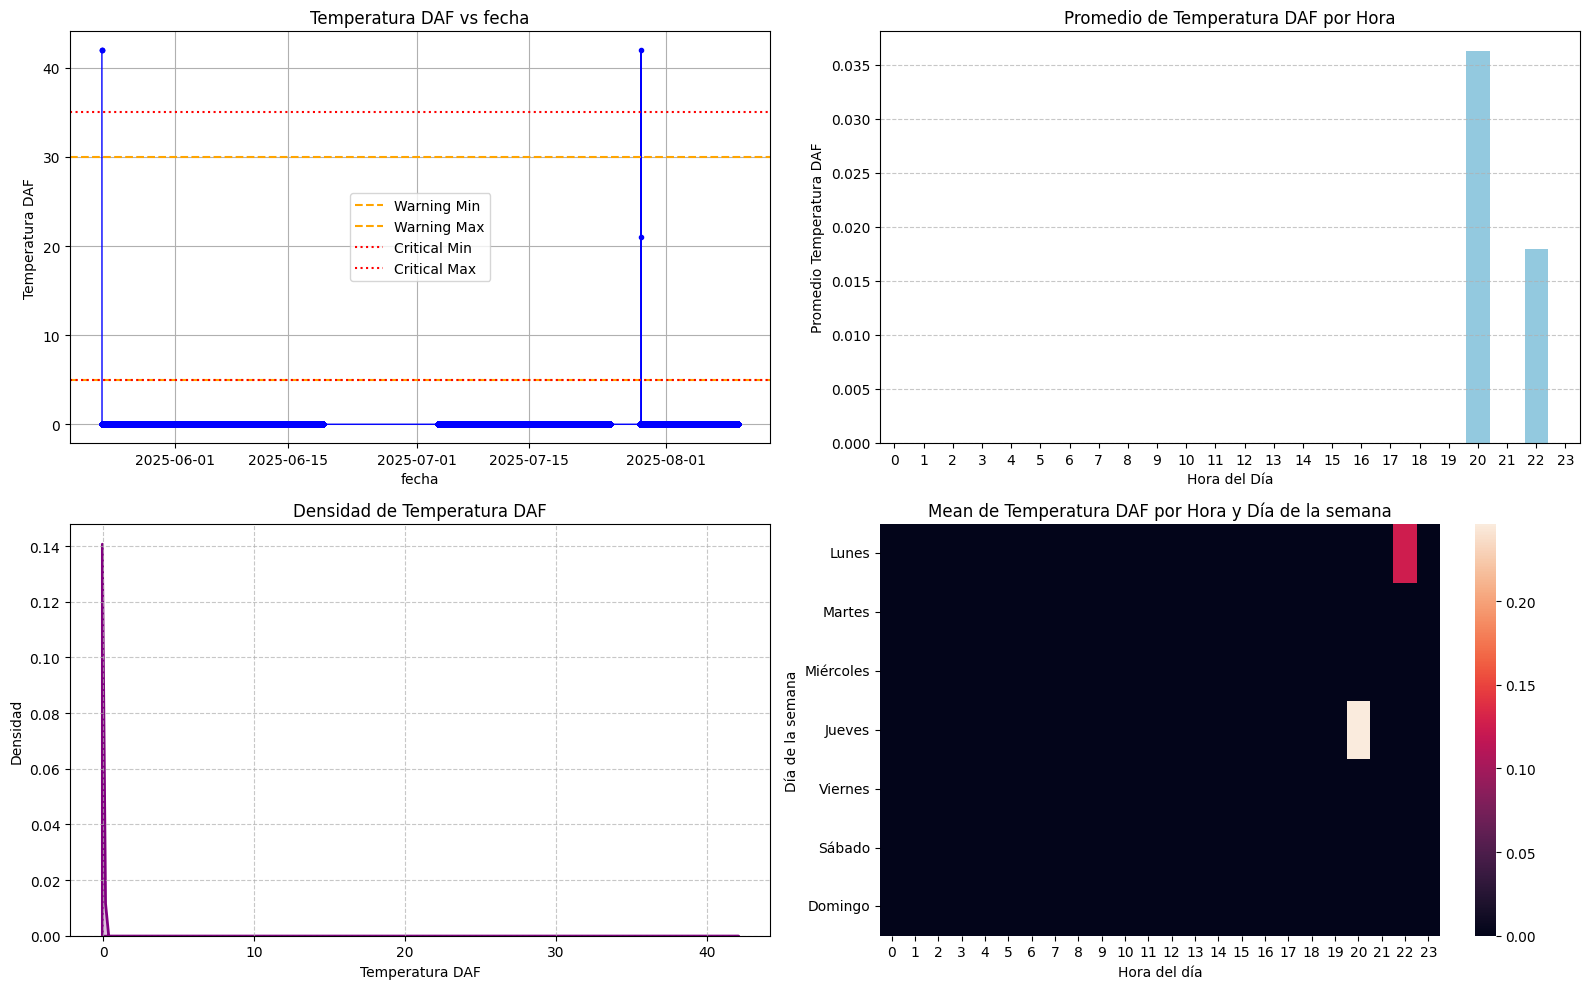

Graficando pH Clarificado DAF (Tk 80m3) (se agregan límites si existen)


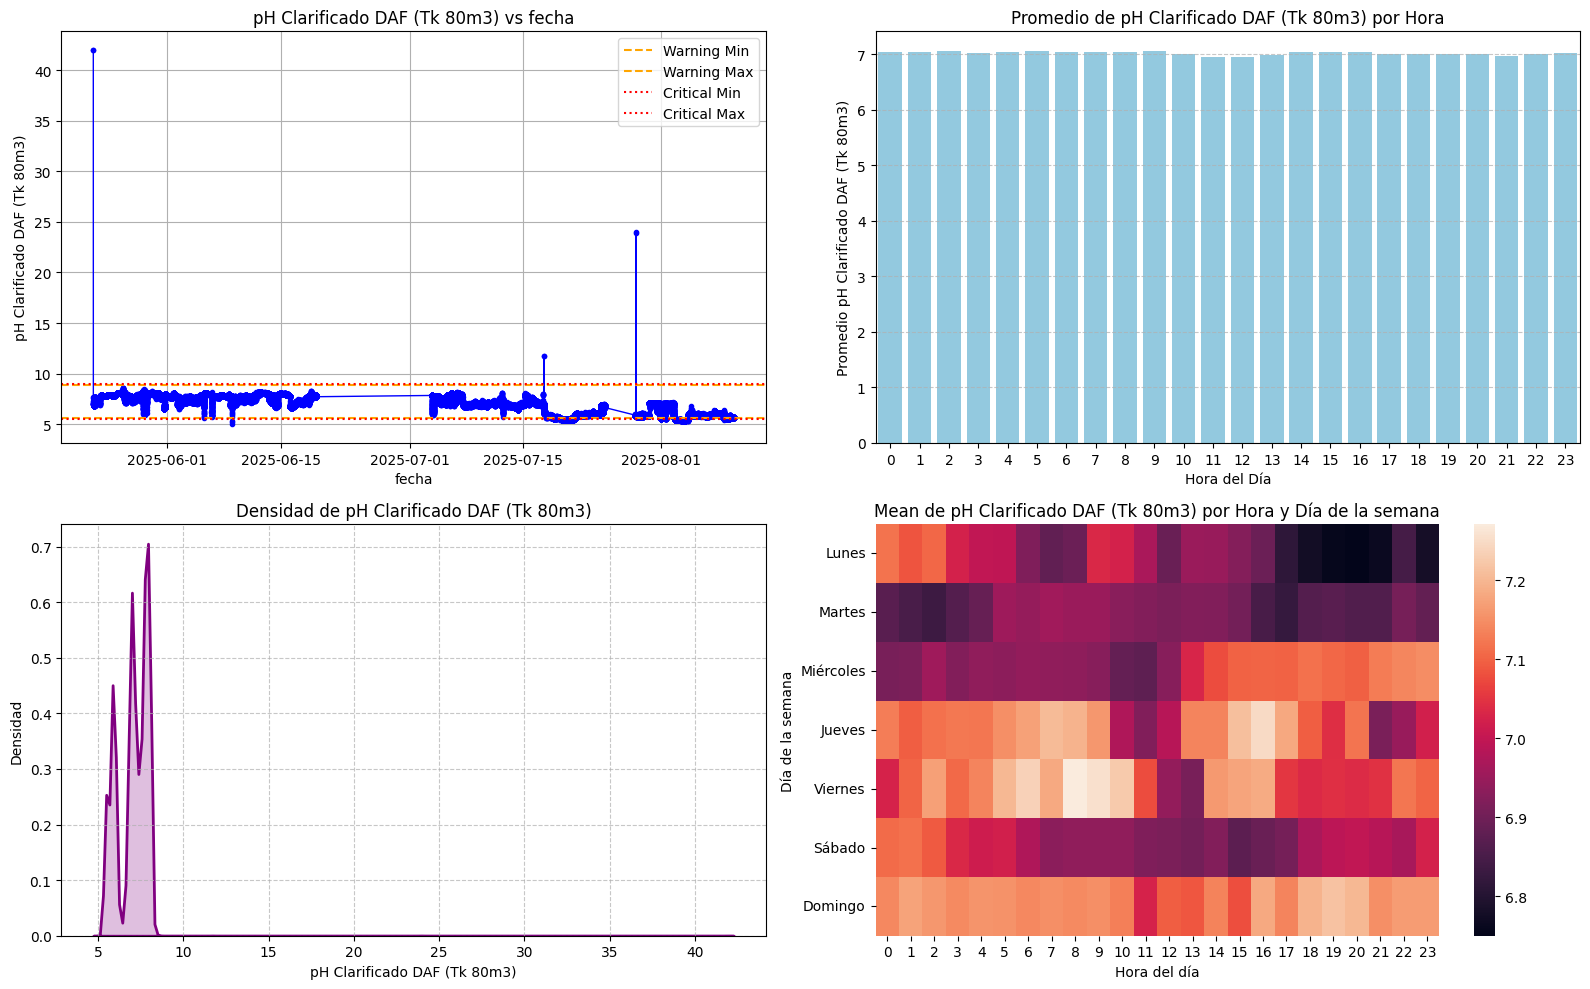

Graficando pH Ecualizador 2 (Tk 250m3) (se agregan límites si existen)


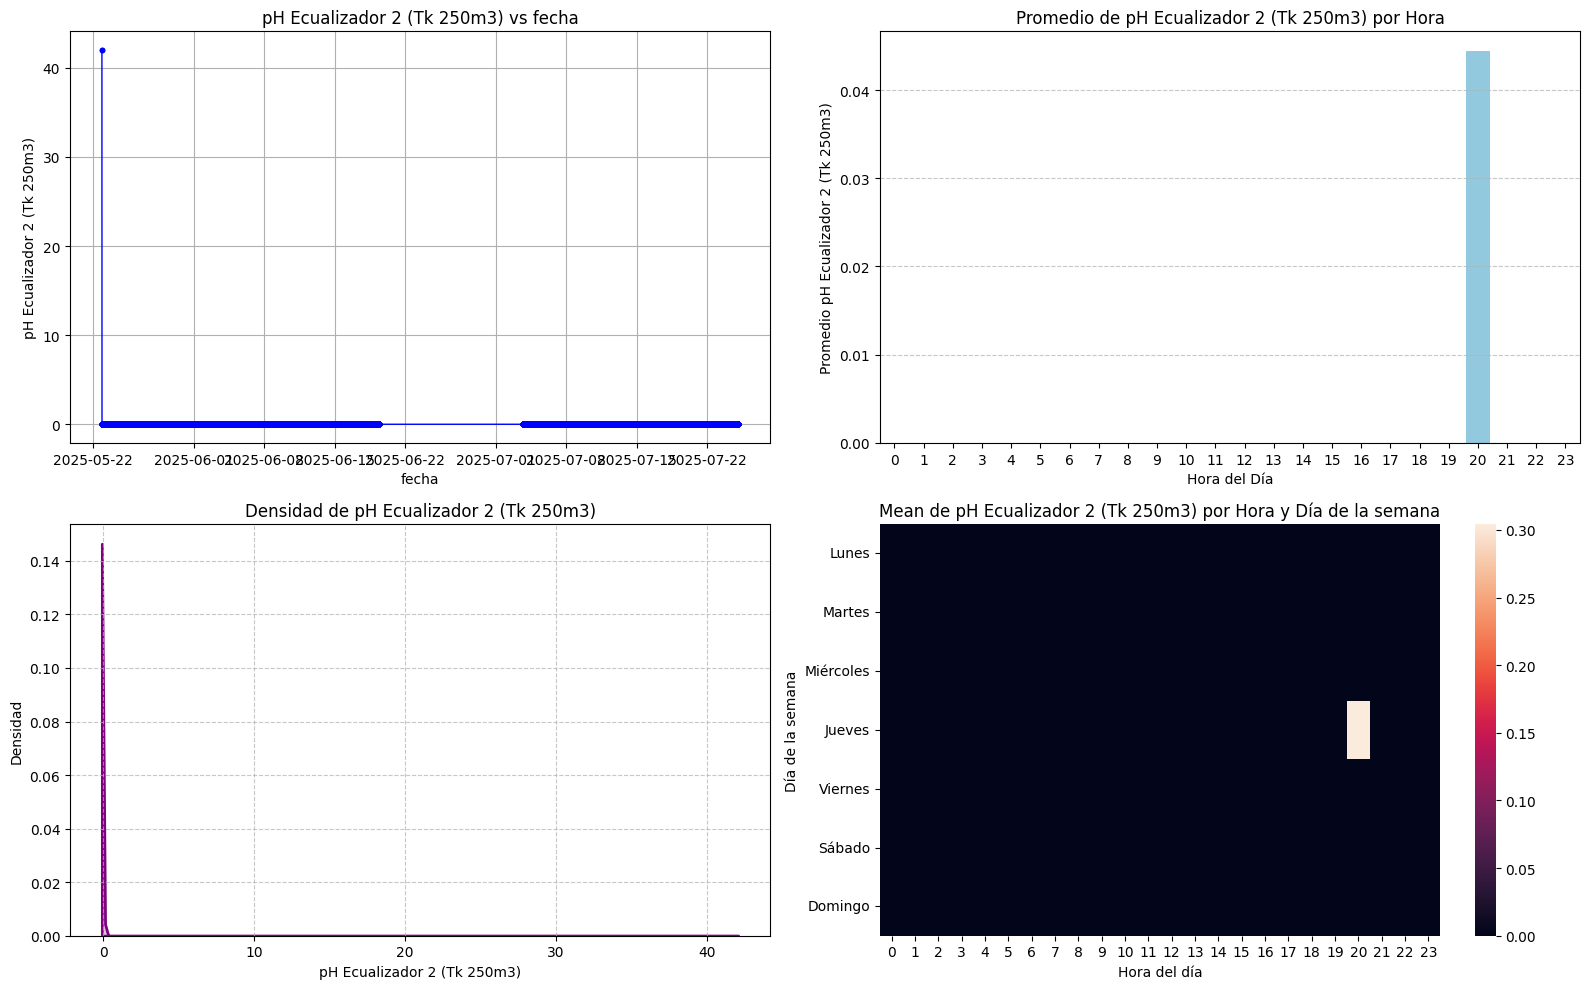

Graficando pH coagulación entrada DAF (se agregan límites si existen)


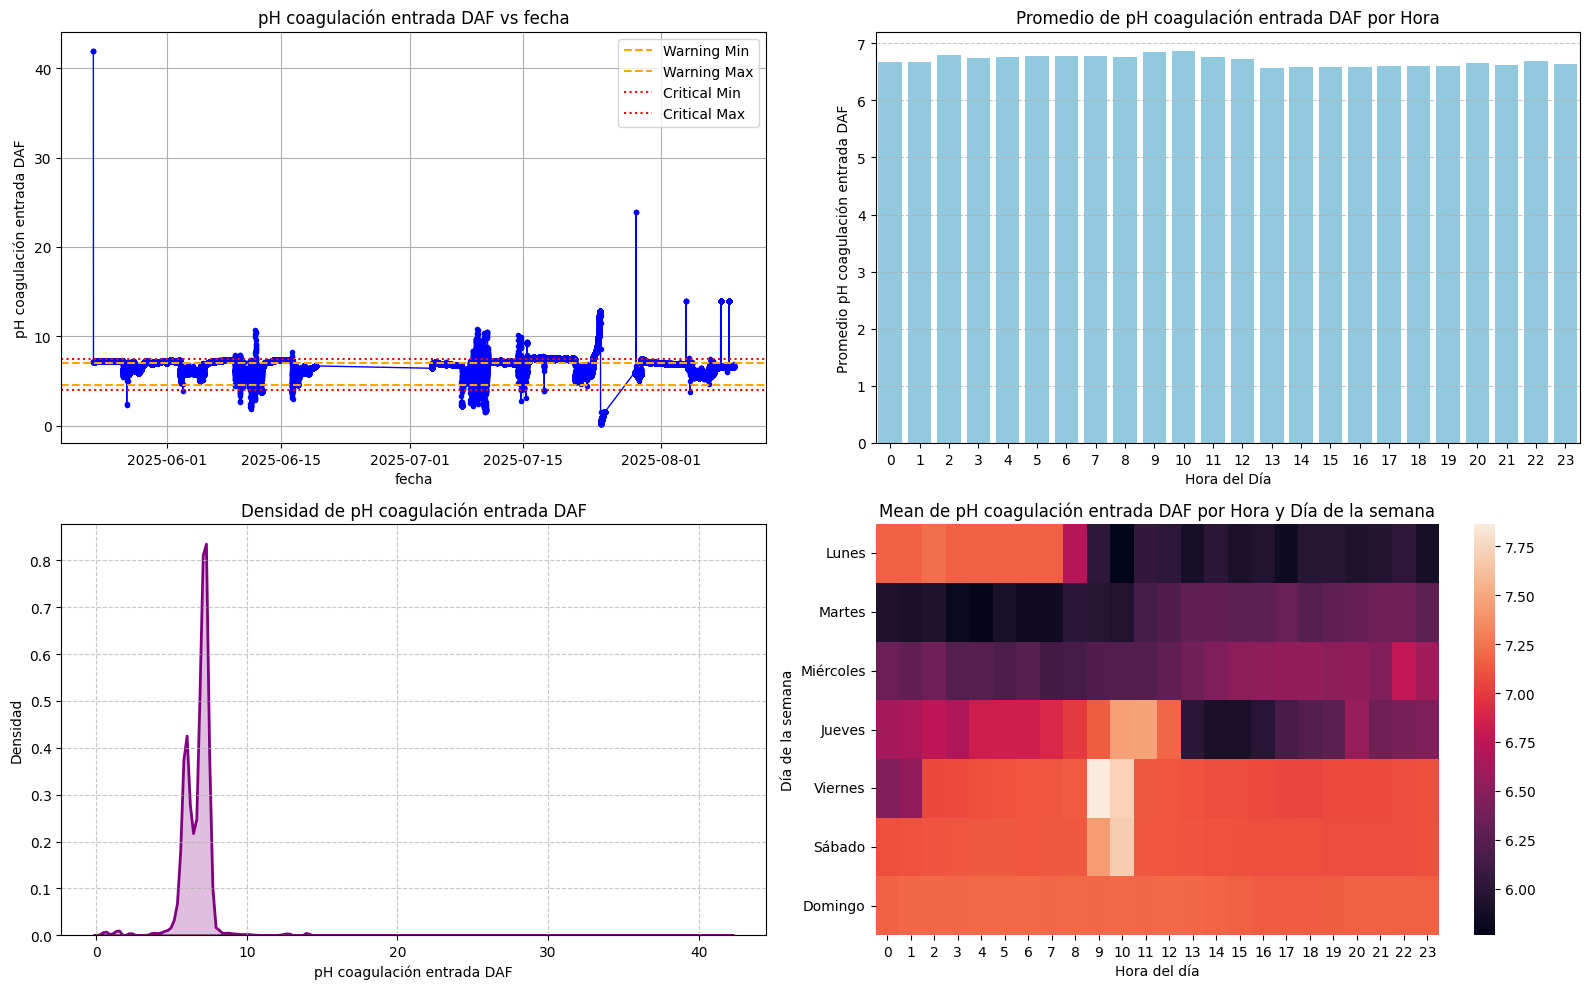

Graficando pH entrada a Ecualizador 2 (Tk 250m3) (se agregan límites si existen)


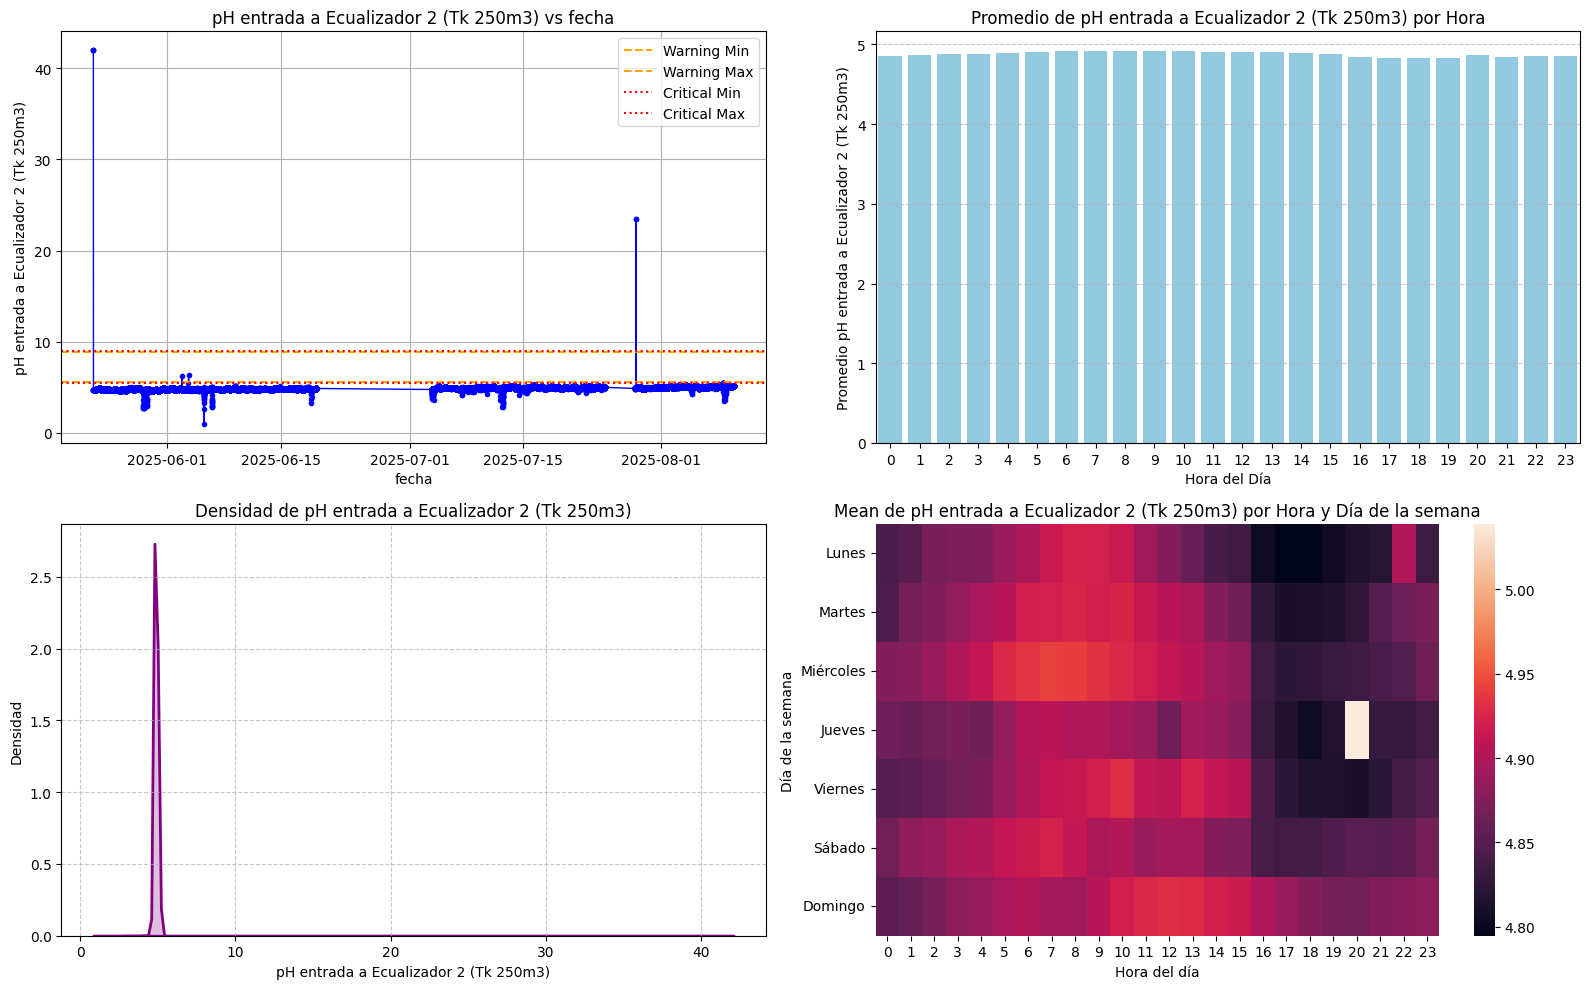

Graficando pH salida a Parshall 02 (se agregan límites si existen)


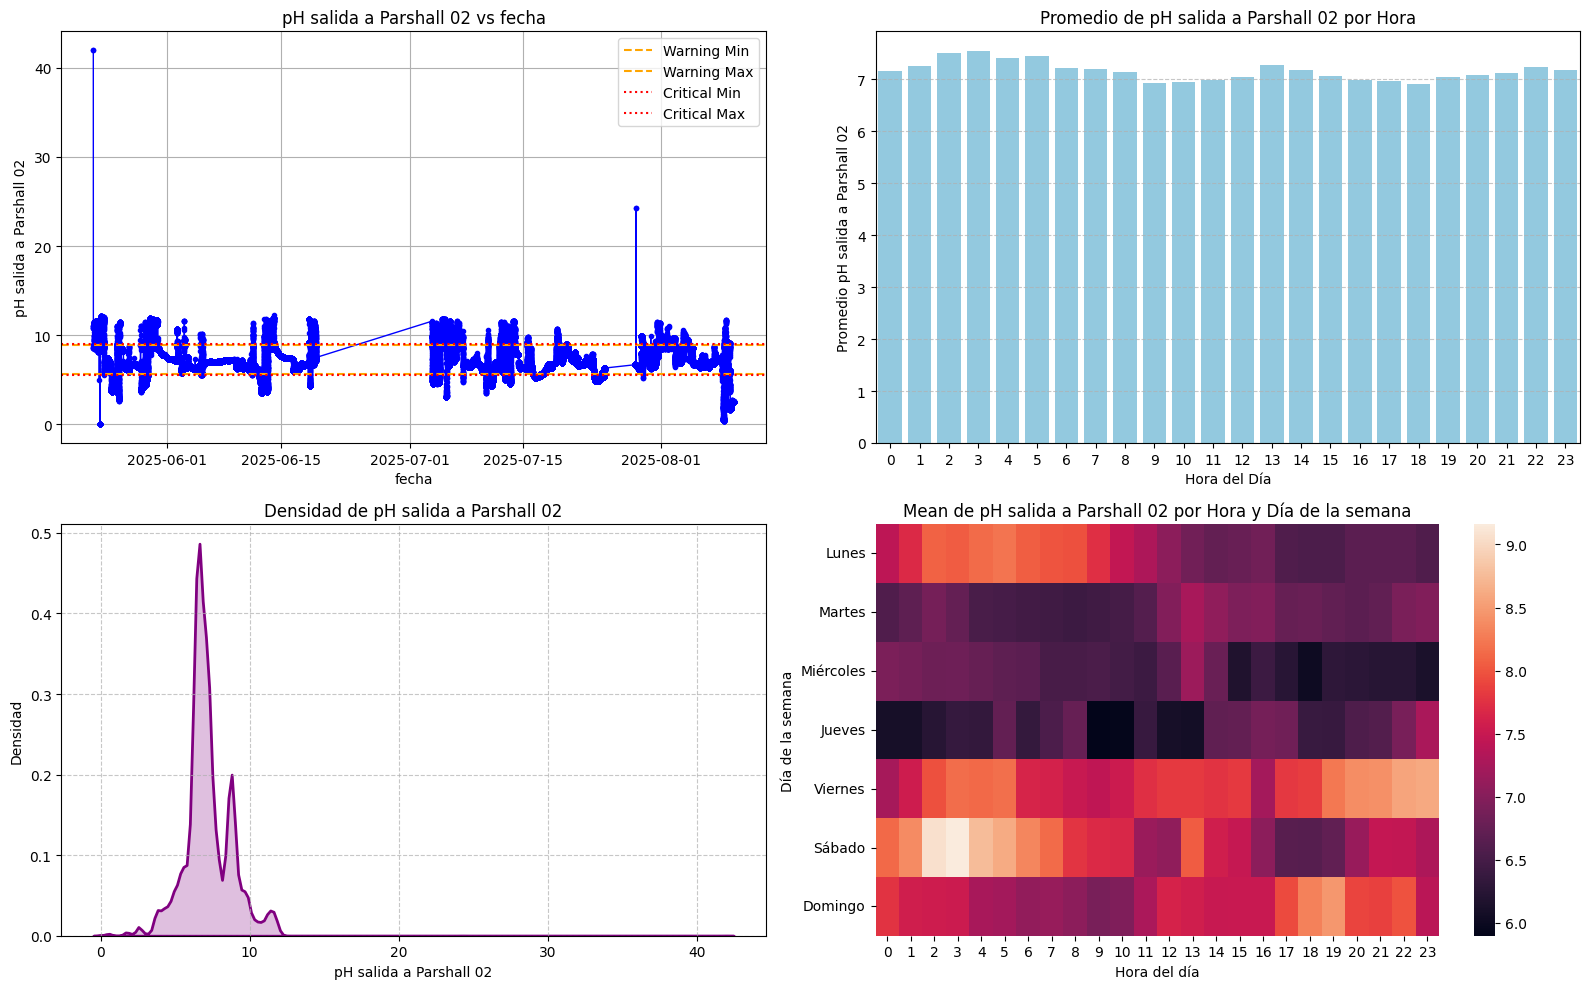

Graficando Nivel Clarificado DAF (Tk 80m3) (se agregan límites si existen)


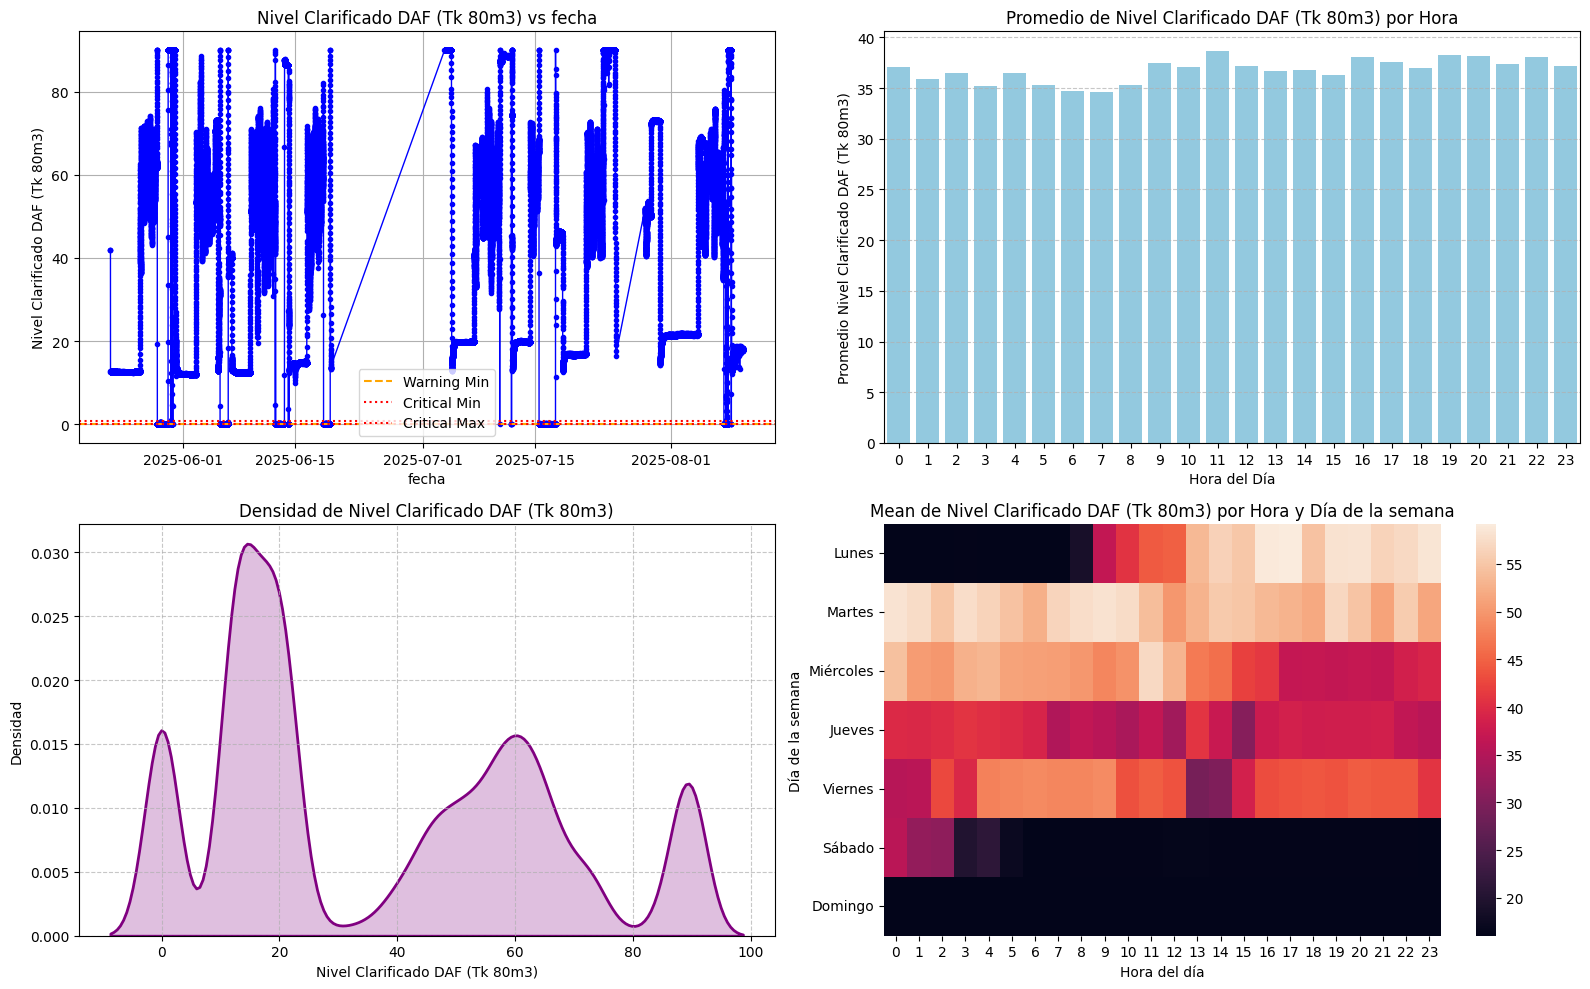

Graficando pH entrada a Ecualizador 1 (se agregan límites si existen)


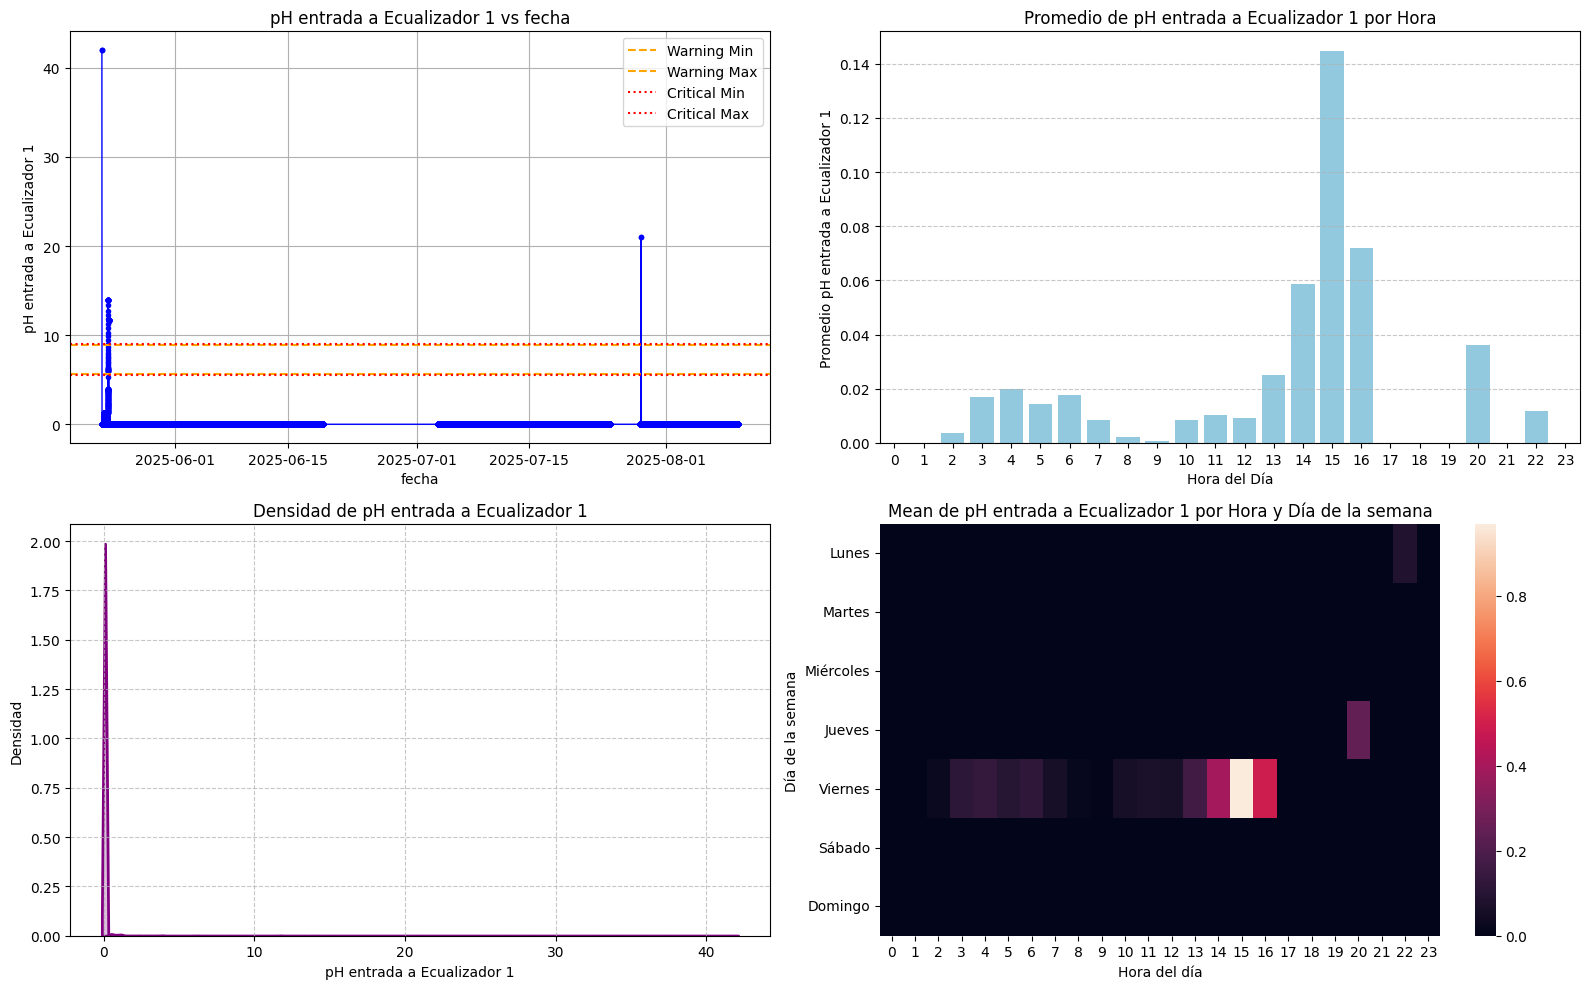

Graficando Turbidez salida DAF (se agregan límites si existen)


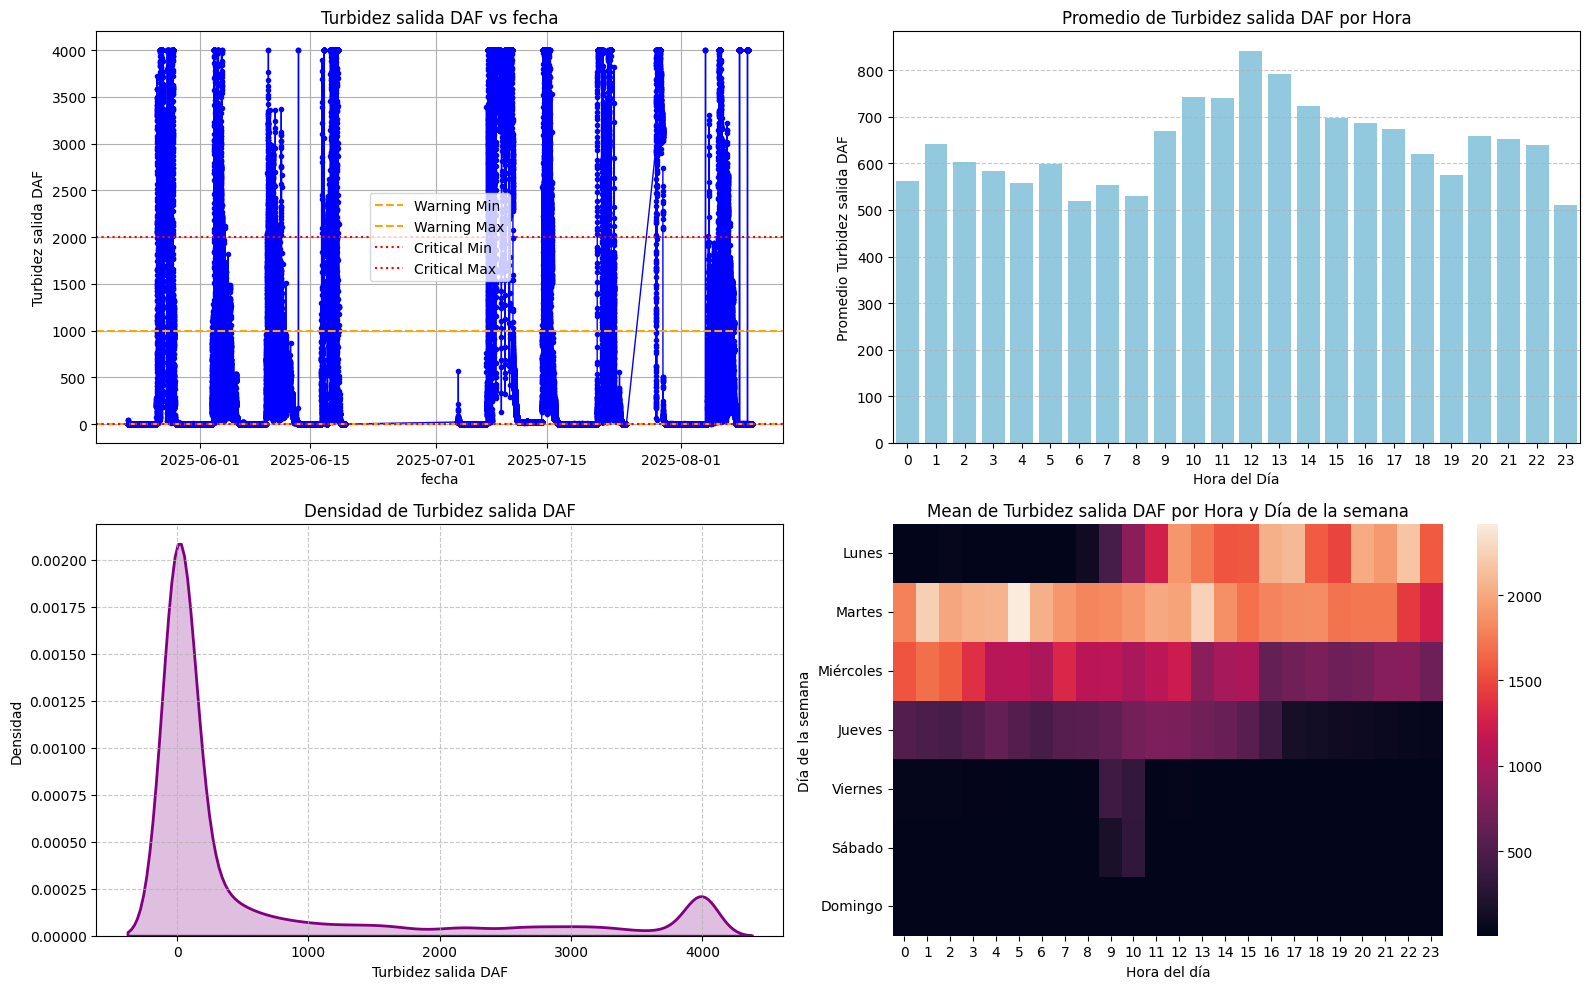

Graficando pH salida y control Ecualizador 1 (se agregan límites si existen)


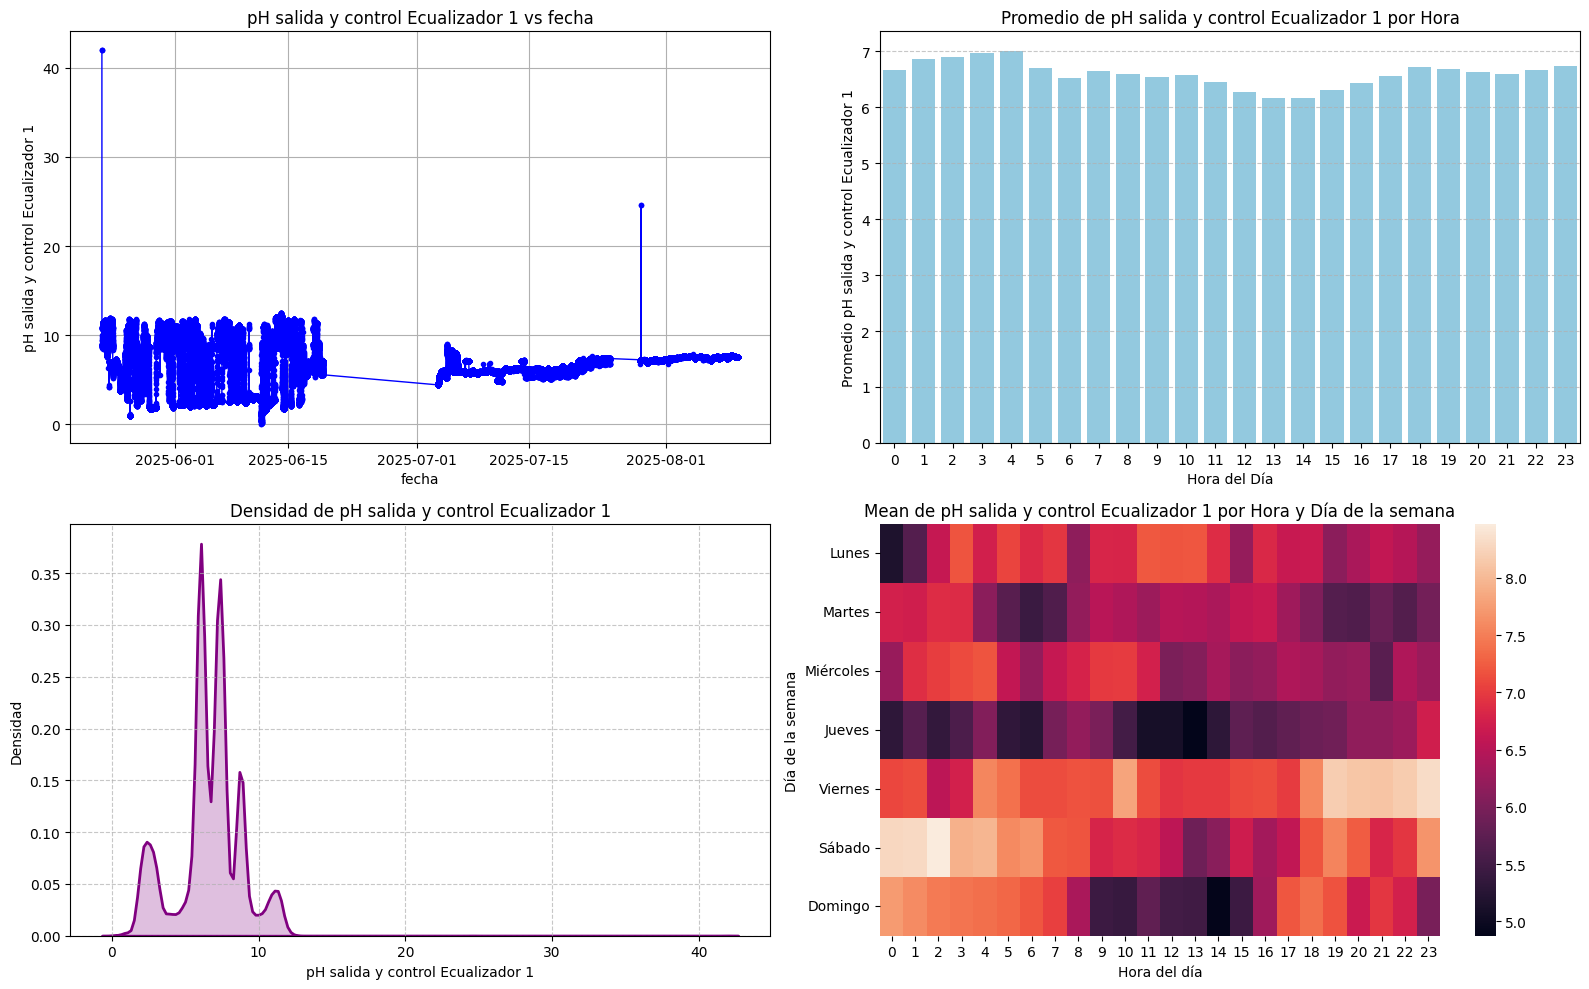

In [10]:
# Plot 4 Gráficos por Columna
num_cols = df_planta_1.select_dtypes(include=[np.number]).columns
for col in num_cols:
    print(f'Graficando {col} (se agregan límites si existen)')
    plot_all(df_planta_1, col, desc_df=desc_planta_1)

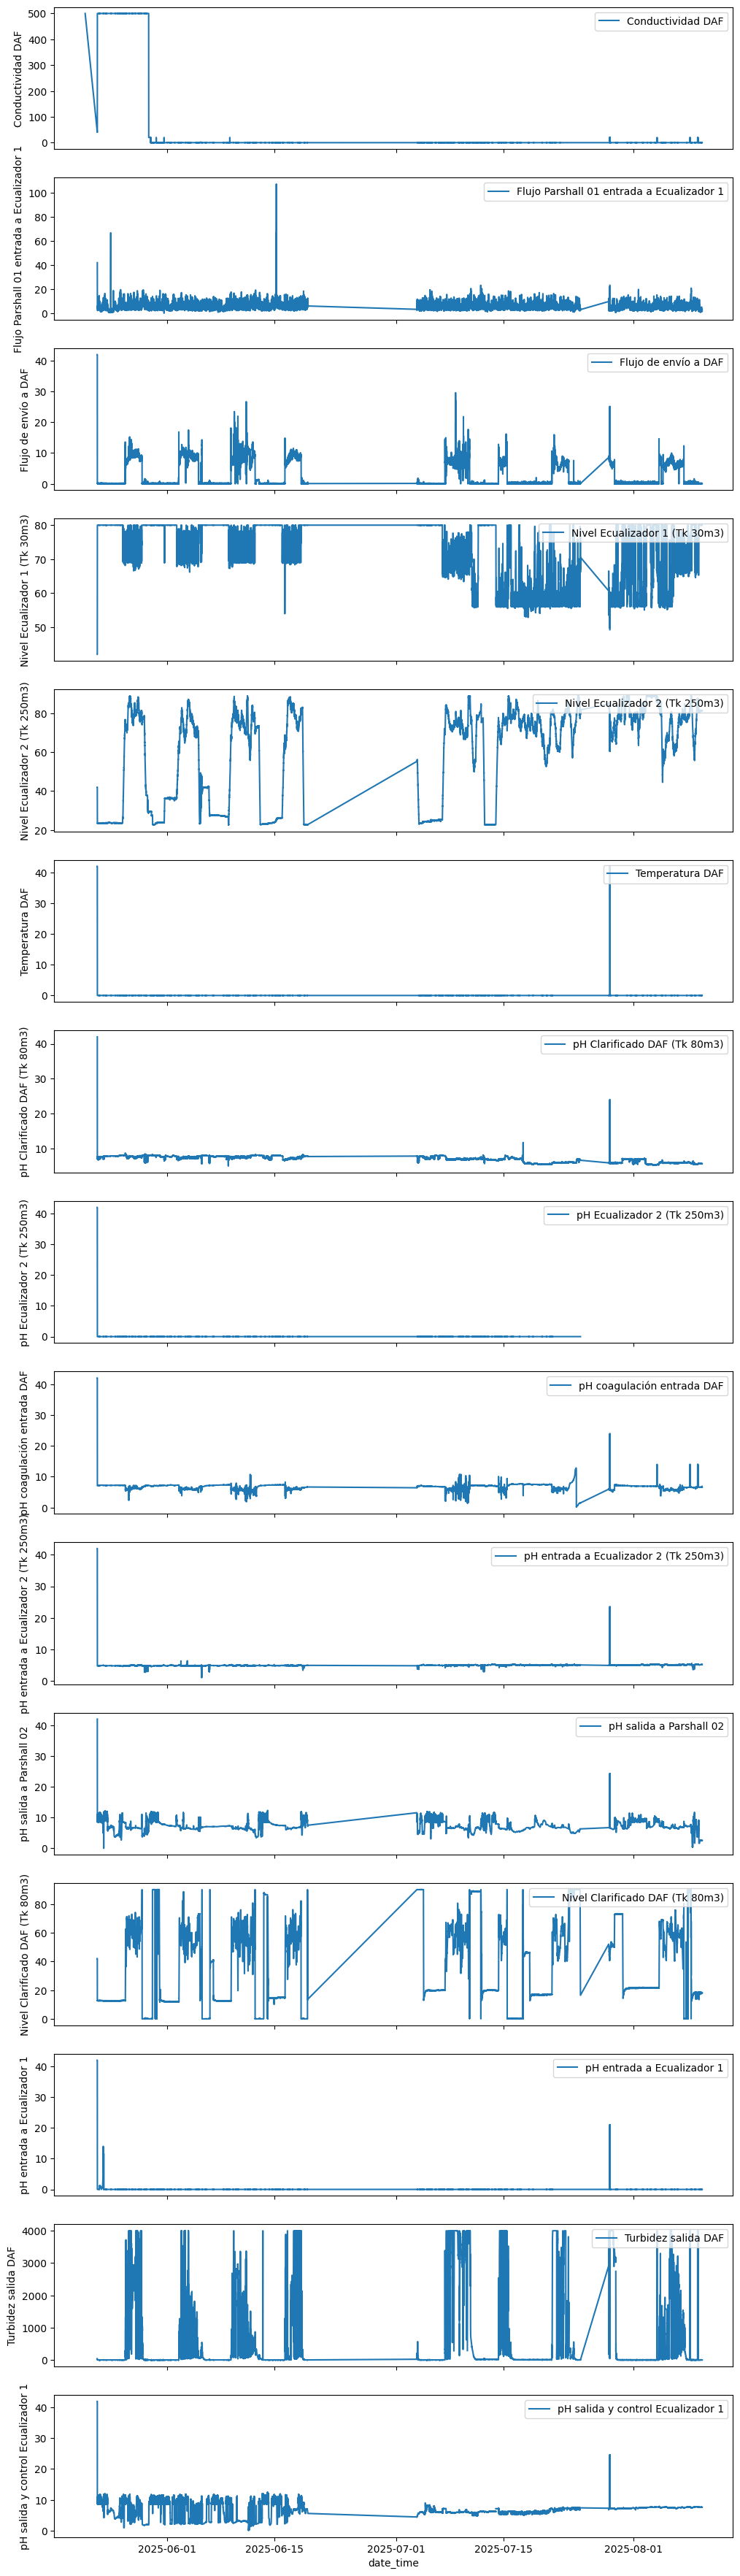

In [11]:
# Plot Series de Tiempo
plot_all_timeseries(df_planta_1)

# Fechas sin Datos

In [12]:
# Fechas sin Datos por Columna
columnas_interes = [col for col in df_planta_1.columns if col != "date_time"]
analizar_columnas_por_fecha(df_planta_1, columnas_interes)


 Análisis de: 'Conductividad DAF'

Fechas con datos:
[2025-05-22, 2025-06-19], 29 días
[2025-07-03, 2025-07-25], 23 días
[2025-07-28, 2025-08-09], 13 días

Total fechas con datos: 65 (81.25%)

Fechas sin datos:
[2025-06-20, 2025-07-02], 13 días
[2025-07-26, 2025-07-27], 2 días

Total fechas sin datos: 15 (18.75%)


 Análisis de: 'Flujo Parshall 01 entrada a Ecualizador 1'

Fechas con datos:
[2025-05-22, 2025-06-19], 29 días
[2025-07-03, 2025-07-25], 23 días
[2025-07-28, 2025-08-09], 13 días

Total fechas con datos: 65 (81.25%)

Fechas sin datos:
[2025-06-20, 2025-07-02], 13 días
[2025-07-26, 2025-07-27], 2 días

Total fechas sin datos: 15 (18.75%)


 Análisis de: 'Flujo de envío a DAF'

Fechas con datos:
[2025-05-22, 2025-06-19], 29 días
[2025-07-03, 2025-07-25], 23 días
[2025-07-28, 2025-08-09], 13 días

Total fechas con datos: 65 (81.25%)

Fechas sin datos:
[2025-06-20, 2025-07-02], 13 días
[2025-07-26, 2025-07-27], 2 días

Total fechas sin datos: 15 (18.75%)


 Análisis de: 'Nivel 

In [13]:
from funciones_pre_procesamiento import huecos_por_columna
res = huecos_por_columna(df_planta_1, "Flujo de envío a DAF",
                         dt_col="date_time",
                         min_gap_minutes=10,
                         merge_gap_minutes=2)
for b in res["huecos"][:5]:
    print(b)


c:\Users\frncc\OneDrive - Universidad Católica de Chile\Desktop\UC\2025-2\Proyecto de Grado\Proyecto-Grado\Pre-Procesamiento\funciones_pre_procesamiento.py:305: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  d["minute"] = d[dt_col].dt.floor("T")


{'inicio': '2024-08-13T00:00:00', 'fin': '2025-05-22T20:31:00', 'minutos': 407312}
{'inicio': '2025-05-22T21:30:00', 'fin': '2025-05-22T22:03:00', 'minutos': 34}
{'inicio': '2025-05-24T12:38:00', 'fin': '2025-05-24T13:26:00', 'minutos': 49}
{'inicio': '2025-06-19T10:00:00', 'fin': '2025-07-03T15:48:00', 'minutos': 20509}
{'inicio': '2025-07-25T01:53:00', 'fin': '2025-07-28T18:27:00', 'minutos': 5315}


c:\Users\frncc\OneDrive - Universidad Católica de Chile\Desktop\UC\2025-2\Proyecto de Grado\Proyecto-Grado\Pre-Procesamiento\funciones_pre_procesamiento.py:312: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(has_data_min.index.min(), has_data_min.index.max(), freq="T")


# Ventanas Activas

c:\Users\frncc\OneDrive - Universidad Católica de Chile\Desktop\UC\2025-2\Proyecto de Grado\Proyecto-Grado\Pre-Procesamiento\funciones_pre_procesamiento.py:467: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  d = d.asfreq(freq)


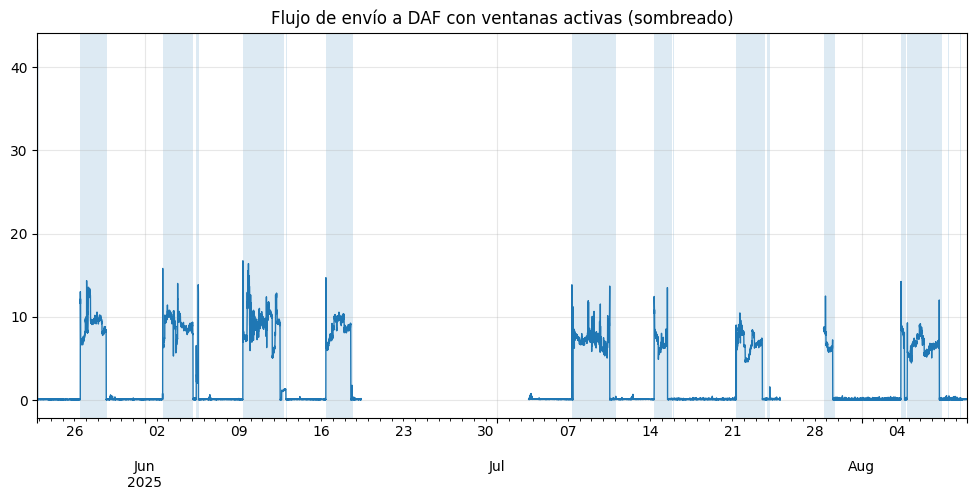

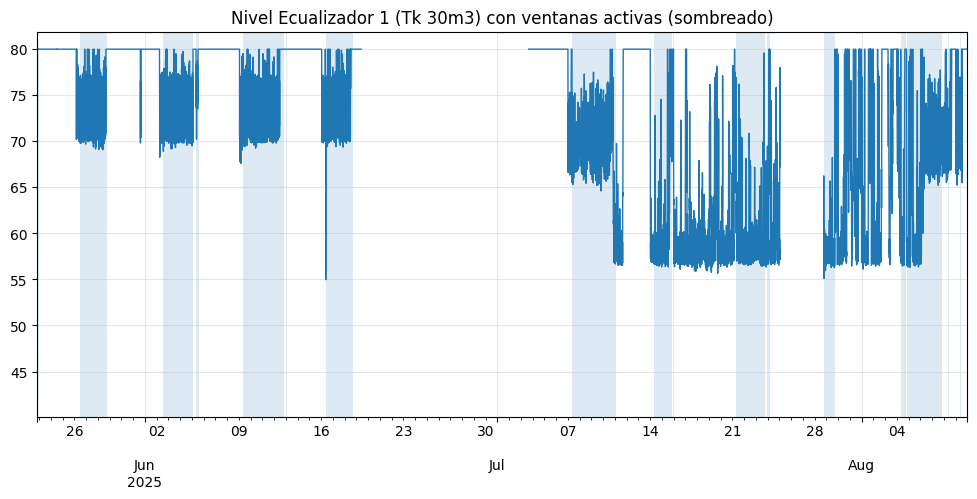

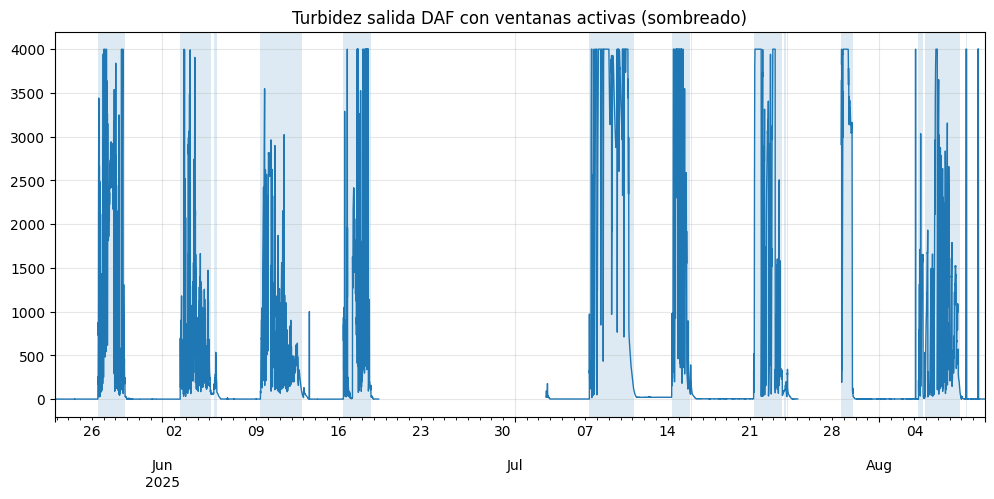

In [14]:
# Ventanas Activas
df = df_planta_1.copy()
df["date_time"] = pd.to_datetime(df["date_time"])

# Reglas de activación (OR entre reglas)
rules = {
    "Flujo de envío a DAF": {"op": ">", "thr": 2},
    "Turbidez salida DAF": {"op": ">", "thr": 100},
    "Nivel Ecualizador 2 (Tk 250m3)": {"op": "diff>", "thr": 1.0},  # movimiento
}

# Flag estable (closing + merge de gaps) y bloques
flag = build_active_flag(
    df, "date_time", rules,
    smooth_window=30,
    min_block_len=30,
    close_window=9,       # tapa microcortes ~9'
    max_gap_minutes=25,   # funde tramos separados por <=25'
    edge_buffer=3         # opcional: expande 3' por lado
)

blocks_activos = blocks_from_flag(df, "date_time", flag)

# Ver rápidamente si marca bien en 3 variables clave:
for col in [
    "Flujo de envío a DAF",
    "Nivel Ecualizador 1 (Tk 30m3)",
    "Turbidez salida DAF",
]:
    plot_with_active_blocks(df, "date_time", col, blocks_activos, resample="5min")

In [15]:
df_planta_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82380 entries, 0 to 82379
Data columns (total 16 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   date_time                                  82380 non-null  datetime64[ns]
 1   Conductividad DAF                          81992 non-null  float64       
 2   Flujo Parshall 01 entrada a Ecualizador 1  81994 non-null  float64       
 3   Flujo de envío a DAF                       81996 non-null  float64       
 4   Nivel Ecualizador 1 (Tk 30m3)              82001 non-null  float64       
 5   Nivel Ecualizador 2 (Tk 250m3)             82005 non-null  float64       
 6   Temperatura DAF                            82007 non-null  float64       
 7   pH Clarificado DAF (Tk 80m3)               82007 non-null  float64       
 8   pH Ecualizador 2 (Tk 250m3)                67566 non-null  float64       
 9   pH coagulación en

In [20]:
df_planta_1 = df_planta_1.sort_values("date_time").set_index("date_time")
df_planta_1["planta1_activa"] = flag.reindex(df_planta_1.index, fill_value=False).astype(bool)

# Si prefieres seguir trabajando con date_time como columna:
df_planta_1 = df_planta_1.reset_index()

# Elimina filas donde todas las columnas excepto 'date_time' y 'planta1_activa' son NaN
cols_to_check = [c for c in df_planta_1.columns if c not in ["date_time", "planta1_activa"]]
df_planta_1 = df_planta_1.dropna(subset=cols_to_check, how="all")

# Save File

In [24]:
df_planta_1

,date_time,Conductividad DAF,Flujo Parshall 01 entrada a Ecualizador 1,Flujo de envío a DAF,Nivel Ecualizador 1 (Tk 30m3),Nivel Ecualizador 2 (Tk 250m3),Temperatura DAF,pH Clarificado DAF (Tk 80m3),pH Ecualizador 2 (Tk 250m3),pH coagulación entrada DAF,pH entrada a Ecualizador 2 (Tk 250m3),pH salida a Parshall 02,Nivel Clarificado DAF (Tk 80m3),pH entrada a Ecualizador 1,Turbidez salida DAF,pH salida y control Ecualizador 1,planta1_activa
0,2025-05-21 06:29:00,500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,2025-05-22 20:31:00,42.000000,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2,2025-05-22 20:32:00,NaN,NaN,42.000000,42.0,42.000000,42.0,NaN,42.0,42.000000,42.000000,NaN,42.000000,42.0,42.000000,42.000000,True
3,2025-05-22 20:41:00,42.000000,42.000000,42.000000,42.0,42.000000,42.0,42.000000,42.0,42.000000,42.000000,42.000000,42.000000,42.0,42.000000,42.000000,True
4,2025-05-22 20:46:00,500.000000,5.361979,0.086806,80.0,23.336227,0.0,7.057220,0.0,7.092665,4.702619,11.059029,12.718099,0.0,0.000000,8.627882,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82281,2025-08-09 23:54:00,0.108507,2.517361,0.086806,80.0,81.270256,0.0,5.654079,NaN,6.619213,5.152778,2.535880,17.985025,0.0,1.880787,7.558855,False
82282,2025-08-09 23:55:00,0.105613,2.341146,0.075955,80.0,81.319443,0.0,5.656106,NaN,6.612124,5.154803,2.539930,17.757160,0.0,2.170139,7.562847,False
82283,2025-08-09 23:56:00,0.105613,2.089410,0.119358,80.0,81.270256,0.0,5.654586,NaN,6.618707,5.154803,2.552083,18.255209,0.0,1.446759,7.562847,False
82284,2025-08-09 23:57:00,0.107060,1.988715,0.108507,80.0,81.333916,0.0,5.649523,NaN,6.601996,5.155310,2.558160,17.848309,0.0,2.459491,7.562847,False


In [25]:
os.makedirs('df_procesados', exist_ok=True)

df_planta_1.to_csv('../df_procesados/df_planta_1.csv', index=False)